## 1. Data Exploration and Preparation
### 1.1 Data Loading and Cleaning

Import necessary libraries and load the dataset from Excel. Perform an initial inspection to identify missing values and remove rows with missing Area entries, as they likely result from formatting issues. Convert the Date column to a proper datetime format and review missing values in key contaminant fields for further cleaning.

In [16]:
# Import necessary libraries and configurations
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
# Test for each contaminant
import statsmodels.formula.api as smf
warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# 1. Data Loading and Inspection
data = pd.read_excel('Project2Data.xls', engine='xlrd')
print(data.head())

# 2. Data Exploration and Cleaning
# Check the missing data
missing_values = data.isnull().sum()
print("Missing values in each column:\n", missing_values)

# 3. Remove the rows when Area is missing, those are not useful for analysis possibly just mis formatting
data = data[data['Area'].notna()]

# Convert date if not already done
data['Date'] = pd.to_datetime(data['Date'])

# 4. Identify rows where 'CanContaminant' is missing since it is the only column with missing values now
missing_can = data[data['CanContaminant'].isnull()]
print("The row when CanContaminant is missing:\n", missing_can)


     Area       Date  PaperContaminant  PlasticContaminant  CanContaminant  \
0     NaN        NaT               NaN                 NaN             NaN   
1     NaN        NaT               NaN                 NaN             NaN   
2  ENGINE 2020-01-15          0.714286           35.340136        0.869565   
3     NaN        NaT               NaN                 NaN             NaN   
4     NaN        NaT               NaN                 NaN             NaN   

   FirstTrialPhase  
0              NaN  
1              NaN  
2              1.0  
3              NaN  
4              NaN  
Missing values in each column:
 Area                  170
Date                  170
PaperContaminant      170
PlasticContaminant    170
CanContaminant        172
FirstTrialPhase       170
dtype: int64
The row when CanContaminant is missing:
        Area       Date  PaperContaminant  PlasticContaminant  CanContaminant  \
41   ENGINE 2020-02-02               0.0                 0.0             NaN   
173

### 1.2 Investigation of Missing CanContaminant Values

Analyze rows with missing CanContaminant values, focusing on data around the date 2020-02-02. This helps determine if zeros in PaperContaminant and PlasticContaminant represent genuine measurements or data entry errors.

In [17]:
# Look at data around 2020-02-02
import pandas as pd

# Get data from a week before and after 2020-02-02
target_date = pd.to_datetime('2020-02-02')
date_range = data[
    (data['Date'] >= target_date - pd.Timedelta(days=5)) &
    (data['Date'] <= target_date + pd.Timedelta(days=5))
].sort_values('Date')

print("Data around 2020-02-02:")
print(date_range[['Date', 'Area', 'FirstTrialPhase', 'PaperContaminant', 'PlasticContaminant', 'CanContaminant']])

Data around 2020-02-02:
          Date    Area  FirstTrialPhase  PaperContaminant  PlasticContaminant  \
29  2020-01-29  ENGINE              1.0          0.857143           49.018044   
161 2020-01-29   UTOWN              1.0         13.111111           61.314081   
32  2020-01-30  ENGINE              1.0          0.400000           53.632957   
164 2020-01-30   UTOWN              1.0          2.444444           54.861025   
35  2020-01-31  ENGINE              1.0          1.428571           60.707071   
167 2020-01-31   UTOWN              1.0          4.222222           65.943798   
38  2020-02-01  ENGINE              1.0          1.285714           14.074074   
170 2020-02-01   UTOWN              1.0          2.777778           66.241794   
41  2020-02-02  ENGINE              1.0          0.000000            0.000000   
173 2020-02-02   UTOWN              1.0          0.000000            0.000000   
44  2020-02-03  ENGINE              1.0          0.666667           52.839506   
176 

### 1.3 Removal of Invalid Data Points

The contamination values on 2020-02-02 appear anomalous and inconsistent with surrounding dates, indicating a probable data collection issue. Since both treatment and control locations are equally affected, removing this date maintains the validity of the Difference-in-Differences (DiD) assumptions and ensures data integrity.

In [18]:
# Remove 2020-02-02 from dataset
df_clean = data[data['CanContaminant'].notna()]

print(f"After removing 2020-02-02: {len(data)} rows")
print(f"Rows removed: {len(data) - len(df_clean)} (1 per location, balanced removal)")

# Verify no remaining missing values
print("\nRemaining missing values:")
print(df_clean[['PaperContaminant', 'PlasticContaminant', 'CanContaminant']].isnull().sum())

# Use cleaned dataset for all subsequent analyses
df = df_clean.copy()
print(f"\nFinal clean dataset: {len(df)} rows")

After removing 2020-02-02: 85 rows
Rows removed: 2 (1 per location, balanced removal)

Remaining missing values:
PaperContaminant      0
PlasticContaminant    0
CanContaminant        0
dtype: int64

Final clean dataset: 83 rows


### 1.4 Ensuring a Balanced Structure

Verify that both treatment (ENGINE) and control (UTOWN) areas have observations for the same set of dates. This step ensures a balanced dataset necessary for valid Difference-in-Differences analysis.

In [19]:
# Find which dates each location has
engine_dates = set(df[df['Area'] == 'ENGINE']['Date'])
utown_dates = set(df[df['Area'] == 'UTOWN']['Date'])

# Which dates does ENGINE have that UTOWN doesn't?
engine_only = engine_dates - utown_dates
print("Dates that ENGINE has but UTOWN doesn't:")
for date in sorted(engine_only):
    print(f"  {date.strftime('%Y-%m-%d')}")
    # Show the ENGINE data for that date
    engine_data = df[(df['Area'] == 'ENGINE') & (df['Date'] == date)]
    print(f"    Phase: {engine_data['FirstTrialPhase'].values[0]}")
    print(f"    Paper: {engine_data['PaperContaminant'].values[0]:.2f}%")
    print(f"    Plastic: {engine_data['PlasticContaminant'].values[0]:.2f}%")
    print(f"    Can: {engine_data['CanContaminant'].values[0]:.2f}%")

# Which dates does UTOWN have that ENGINE doesn't?
utown_only = utown_dates - engine_dates
print("\nDates that UTOWN has but ENGINE doesn't:")
for date in sorted(utown_only):
    print(f"  {date.strftime('%Y-%m-%d')}")
    # Show the UTOWN data for that date
    utown_data = df[(df['Area'] == 'UTOWN') & (df['Date'] == date)]
    print(f"    Phase: {utown_data['FirstTrialPhase'].values[0]}")
    print(f"    Paper: {utown_data['PaperContaminant'].values[0]:.2f}%")
    print(f"    Plastic: {utown_data['PlasticContaminant'].values[0]:.2f}%")
    print(f"    Can: {utown_data['CanContaminant'].values[0]:.2f}%")


Dates that ENGINE has but UTOWN doesn't:
  2020-01-16
    Phase: 1.0
    Paper: 1.14%
    Plastic: 43.93%
    Can: 17.17%
  2020-02-07
    Phase: 1.0
    Paper: 0.29%
    Plastic: 41.04%
    Can: 30.84%
  2020-03-10
    Phase: 3.0
    Paper: 0.60%
    Plastic: 57.17%
    Can: 4.17%

Dates that UTOWN has but ENGINE doesn't:
  2020-01-13
    Phase: 1.0
    Paper: 11.22%
    Plastic: 71.20%
    Can: 46.73%
  2020-01-14
    Phase: 1.0
    Paper: 5.89%
    Plastic: 59.00%
    Can: 43.38%


### 1.5 Removal of Unbalanced Observations

Remove dates where data exists for only one area to maintain a balanced panel structure, ensuring the integrity of subsequent comparative analyses.

In [20]:
# Remove unbalanced dates
unbalanced_dates = engine_only | utown_only
df = df[~df['Date'].isin(unbalanced_dates)].copy()

## 2. Exploratory Data Analysis (EDA)

### 2.1 Summary Statistics by Phase and Location

Generating
 descriptive statistics for each contaminant type, grouped by FirstTrialPhase and Area. This provides a high-level understanding of how contamination levels vary across different experimental phases and locations.

In [21]:
# verfiy df['Date'] range
print("Date range:")
print(f"Start: {df['Date'].min()}")
print(f"End: {df['Date'].max()}")
print(f"\nTotal days: {(df['Date'].max() - df['Date'].min()).days}")

# Check unique values for categorical columns
print("Unique Areas:")
print(df['Area'].value_counts())
print("Observations by Phase and Area:")
print(df.groupby(['FirstTrialPhase', 'Area']).size())

Date range:
Start: 2020-01-15 00:00:00
End: 2020-03-17 00:00:00

Total days: 62
Unique Areas:
Area
ENGINE    39
UTOWN     39
Name: count, dtype: int64
Observations by Phase and Area:
FirstTrialPhase  Area  
1.0              ENGINE    17
                 UTOWN     17
2.0              ENGINE    11
                 UTOWN     11
3.0              ENGINE    11
                 UTOWN     11
dtype: int64


Now the data is balanced, we would calculate summary statistics (mean, median, standard deviation) for contamination rates for each phase, location, and recyclable type.

In [22]:
contaminants = ['PaperContaminant', 'PlasticContaminant', 'CanContaminant']
for contaminant in contaminants:
    print(f"\n{contaminant.replace('Contaminant', '')} Contamination (%):")
    material_stats = df.groupby(['FirstTrialPhase', 'Area'])[contaminant].agg([
        'count', 'mean', 'median', 'std', 'min', 'max'
    ])
    print(material_stats.round(2))


Paper Contamination (%):
                        count  mean  median   std   min    max
FirstTrialPhase Area                                          
1.0             ENGINE     17  0.87    0.86  0.39  0.29   1.71
                UTOWN      17  6.10    4.22  3.56  2.44  13.11
2.0             ENGINE     11  1.29    0.57  2.04  0.00   7.20
                UTOWN      11  4.00    3.67  1.48  2.11   7.67
3.0             ENGINE     11  0.77    0.20  1.41  0.00   4.80
                UTOWN      11  4.69    4.11  1.77  2.78   7.78

Plastic Contamination (%):
                        count   mean  median    std    min    max
FirstTrialPhase Area                                             
1.0             ENGINE     17  49.04   49.07  12.14  14.07  67.58
                UTOWN      17  59.73   60.75   6.96  45.96  71.12
2.0             ENGINE     11  35.96   39.06   9.09  18.33  47.93
                UTOWN      11  46.51   47.13   7.23  34.68  57.85
3.0             ENGINE     11  39.39   37.29  

Smooth the trend lines

In [23]:
# Find phase transition dates
phase_dates = df.groupby('FirstTrialPhase')['Date'].agg(['min', 'max'])
print("Phase Date Ranges:")
print(phase_dates)

phase2_start = df[df['FirstTrialPhase'] == 2]['Date'].min()
phase3_start = df[df['FirstTrialPhase'] == 3]['Date'].min()

print(f"\nPhase 2 starts: {phase2_start.strftime('%Y-%m-%d')}")
print(f"Phase 3 starts: {phase3_start.strftime('%Y-%m-%d')}")

Phase Date Ranges:
                       min        max
FirstTrialPhase                      
1.0             2020-01-15 2020-02-10
2.0             2020-02-11 2020-02-22
3.0             2020-03-04 2020-03-17

Phase 2 starts: 2020-02-11
Phase 3 starts: 2020-03-04



### 3.2 Parallel Trends Assessment (Ensuring DiD Validity)

A key assumption of the Difference-in-Differences (DiD) methodology is the **parallel trends assumption**.  
This assumes that, in the absence of the treatment, both groups UTOWN (treatment group) and ENGINE (control group) would have followed similar trends over time during the pre-intervention (Phase 1) period.  

Assessing this condition ensures that any observed divergence in later phases can be attributed to the intervention itself rather than to underlying differences in the groups baseline behavior.


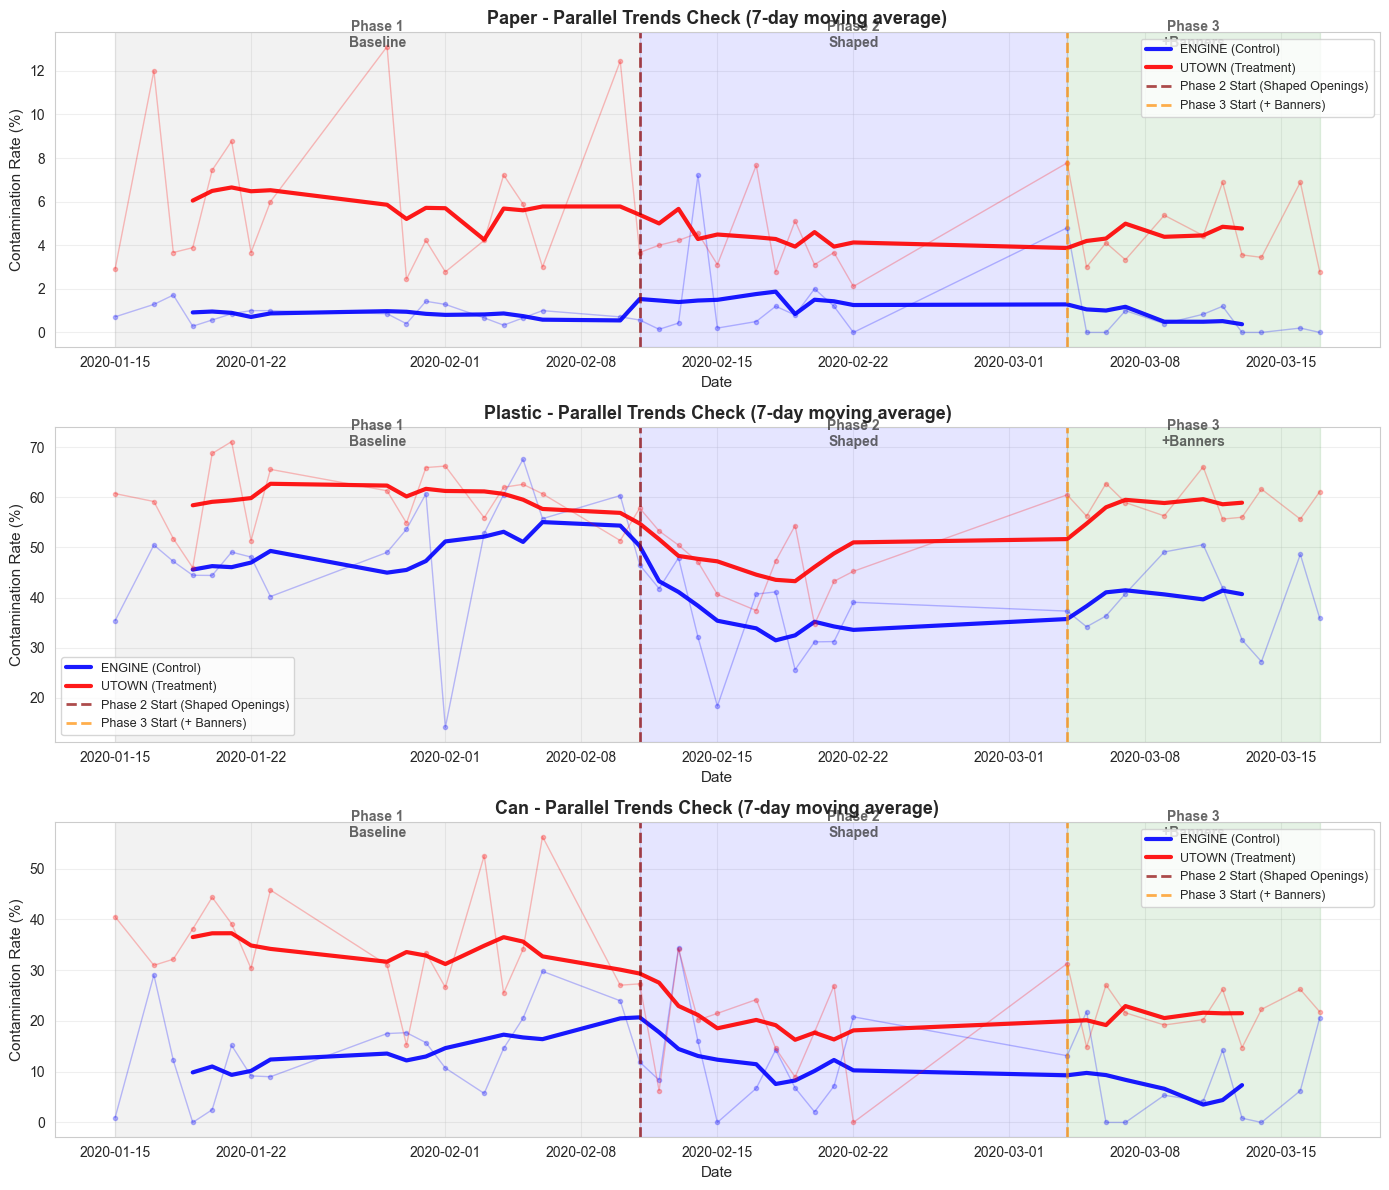

In [24]:
# Time series plots with smoothed trend lines (7-day moving average)
contaminants = ['PaperContaminant', 'PlasticContaminant', 'CanContaminant']
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

for idx, contaminant in enumerate(contaminants):
    
    # Plot for each location
    for area in ['ENGINE', 'UTOWN']:
        data_area = df[df['Area'] == area].sort_values('Date')
        label = f'{area} ({"Control" if area == "ENGINE" else "Treatment"})'
        color = 'blue' if area == 'ENGINE' else 'red'
        
        # Plot raw daily data (faint)
        axes[idx].plot(data_area['Date'], data_area[contaminant], 
                      marker='o', linewidth=1, markersize=3, alpha=0.25,
                      color=color)
        
        # Plot 7-day moving average (bold trend line)
        data_area['smooth'] = data_area[contaminant].rolling(window=7, center=True).mean()
        axes[idx].plot(data_area['Date'], data_area['smooth'], 
                      label=label, linewidth=3, alpha=0.9, color=color)
    
    # Add vertical lines for phase transitions
    axes[idx].axvline(phase2_start, color='darkred', linestyle='--', linewidth=2, 
                     alpha=0.7, label='Phase 2 Start (Shaped Openings)')
    axes[idx].axvline(phase3_start, color='darkorange', linestyle='--', linewidth=2, 
                     alpha=0.7, label='Phase 3 Start (+ Banners)')
    
    # Shade phase regions
    axes[idx].axvspan(df['Date'].min(), phase2_start, alpha=0.1, color='gray')
    axes[idx].axvspan(phase2_start, phase3_start, alpha=0.1, color='blue')
    axes[idx].axvspan(phase3_start, df['Date'].max(), alpha=0.1, color='green')
    
    # Add phase labels
    phase1_mid = df['Date'].min() + (phase2_start - df['Date'].min()) / 2
    phase2_mid = phase2_start + (phase3_start - phase2_start) / 2
    phase3_mid = phase3_start + (df['Date'].max() - phase3_start) / 2
    
    y_pos = axes[idx].get_ylim()[1] * 0.95
    axes[idx].text(phase1_mid, y_pos, 'Phase 1\nBaseline', 
                  ha='center', fontsize=10, fontweight='bold', alpha=0.7)
    axes[idx].text(phase2_mid, y_pos, 'Phase 2\nShaped', 
                  ha='center', fontsize=10, fontweight='bold', alpha=0.7)
    axes[idx].text(phase3_mid, y_pos, 'Phase 3\n+Banners', 
                  ha='center', fontsize=10, fontweight='bold', alpha=0.7)
    
    axes[idx].set_title(f'{contaminant.replace("Contaminant", "")} - Parallel Trends Check (7-day moving average)', 
                       fontsize=13, fontweight='bold')
    axes[idx].set_xlabel('Date', fontsize=11)
    axes[idx].set_ylabel('Contamination Rate (%)', fontsize=11)
    axes[idx].legend(loc='best', fontsize=9)
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('parallel_trends_check.png', dpi=300, bbox_inches='tight')
plt.show()

### 3.3 Statistical Test for Parallel Trends

We formally test the parallel trends assumption by regressing Phase 1 contamination rates on time, treatment status, and their interaction. If the interaction term (Time × IsUTOWN) is not significant, it confirms that both groups had similar trends during the pre-treatment period.

In [25]:
# Parallel Trends Test (Phase 1 Only)
df_phase1 = df[df['FirstTrialPhase'] == 1].copy()
df_phase1['Time'] = (df_phase1['Date'] - df_phase1['Date'].min()).dt.days
df_phase1['IsUTOWN'] = (df_phase1['Area'] == 'UTOWN').astype(int)

print("PARALLEL TRENDS TEST")
print("Model: Contamination ~ Time + IsUTOWN + Time×IsUTOWN")
print("H0: Time×IsUTOWN = 0 (parallel trends holds)\n")

for contaminant in ['PaperContaminant', 'PlasticContaminant', 'CanContaminant']:
    model = smf.ols(f'{contaminant} ~ Time + IsUTOWN + Time:IsUTOWN', data=df_phase1).fit()
    interaction_p = model.pvalues['Time:IsUTOWN']
    status = "✅ Valid" if interaction_p > 0.05 else "❌ Violated"
    
    print(f"{contaminant.replace('Contaminant', ''):10s}: {status} (p={interaction_p:.4f})")

PARALLEL TRENDS TEST
Model: Contamination ~ Time + IsUTOWN + Time×IsUTOWN
H0: Time×IsUTOWN = 0 (parallel trends holds)

Paper     : ✅ Valid (p=0.6999)
Plastic   : ✅ Valid (p=0.1451)
Can       : ✅ Valid (p=0.1299)


## 4. Difference-in-Differences Analysis: Phase 2 (Shaped Openings)

We now estimate the causal effect of shaped openings on contamination rates using the DiD approach.

**DiD Core Idea**: 
```
DiD Effect = (UTOWN_after - UTOWN_before) - (ENGINE_after - ENGINE_before)
```

**Regression Model**: 
```
Contamination = β₀ + β₁*PostPhase2 + β₂*IsUTOWN + δ₁*(PostPhase2 × IsUTOWN) + ε
```

**Key Parameters**:
- `PostPhase2`: Dummy variable (1 if Phase 2, 0 if Phase 1)
- `IsUTOWN`: Dummy variable (1 if UTOWN, 0 if ENGINE)
- **δ₁**: DiD estimator (interaction term) - the causal effect of shaped openings

**Hypotheses**:
- H₀: δ₁ = 0 (no effect)
- H₁: δ₁ ≠ 0 (shaped openings had an effect)


In [26]:
# Phase 2 DiD Analysis: Shaped Openings Effect
# Filter to Phase 1 and Phase 2 only
df_phase2 = df[df['FirstTrialPhase'].isin([1, 2])].copy()

# Create dummy variables
df_phase2['PostPhase2'] = (df_phase2['FirstTrialPhase'] == 2).astype(int)
df_phase2['IsUTOWN'] = (df_phase2['Area'] == 'UTOWN').astype(int)

print(f"Phase 2 analysis sample: {len(df_phase2)} observations")
print(f"  Phase 1: {len(df_phase2[df_phase2['PostPhase2']==0])} obs")
print(f"  Phase 2: {len(df_phase2[df_phase2['PostPhase2']==1])} obs")
print(f"  ENGINE: {len(df_phase2[df_phase2['IsUTOWN']==0])} obs")
print(f"  UTOWN: {len(df_phase2[df_phase2['IsUTOWN']==1])} obs")

# Store results
results_phase2 = {}

# Run DiD regression for each contaminant
for contaminant in ['PaperContaminant', 'PlasticContaminant', 'CanContaminant']:
    print(f"{contaminant.replace('Contaminant', '')} Contamination:")
    
    model = smf.ols(f'{contaminant} ~ PostPhase2 + IsUTOWN + PostPhase2:IsUTOWN', 
                    data=df_phase2).fit()
    
    results_phase2[contaminant] = model
    
    # Extract DiD coefficient (interaction term)
    did_effect = model.params['PostPhase2:IsUTOWN']
    std_error = model.bse['PostPhase2:IsUTOWN']
    p_value = model.pvalues['PostPhase2:IsUTOWN']
    ci_lower = model.conf_int().loc['PostPhase2:IsUTOWN', 0]
    ci_upper = model.conf_int().loc['PostPhase2:IsUTOWN', 1]
    
    print(f"\nDiD Estimate (δ₁): {did_effect:.4f} percentage points")
    print(f"Standard Error: {std_error:.4f}")
    print(f"P-value: {p_value:.4f}")
    print(f"95% Confidence Interval: [{ci_lower:.4f}, {ci_upper:.4f}]")
    
    if p_value < 0.05:
        direction = "decreased" if did_effect < 0 else "increased"
        print(f"✅ SIGNIFICANT: Shaped openings {direction} contamination by {abs(did_effect):.2f} percentage points")
    else:
        print(f"❌ NOT SIGNIFICANT: No statistically significant effect detected")
    
    print(f"\nInterpretation:")
    print(f"After shaped openings, UTOWN's contamination changed by {did_effect:.2f} percentage")
    print(f"points MORE than ENGINE's change (controlling for time trends).")
    
    # Show regression coefficients
    print(f"\nRegression Coefficients:")
    print(f"  Intercept (β₀): {model.params['Intercept']:.4f} - ENGINE baseline (Phase 1)")
    print(f"  PostPhase2 (β₁): {model.params['PostPhase2']:.4f} - Time trend (ENGINE change)")
    print(f"  IsUTOWN (β₂): {model.params['IsUTOWN']:.4f} - UTOWN baseline difference")
    print(f"  PostPhase2:IsUTOWN (δ₁): {did_effect:.4f} - DiD TREATMENT EFFECT ⭐")

Phase 2 analysis sample: 56 observations
  Phase 1: 34 obs
  Phase 2: 22 obs
  ENGINE: 28 obs
  UTOWN: 28 obs
Paper Contamination:

DiD Estimate (δ₁): -2.5234 percentage points
Standard Error: 1.2441
P-value: 0.0477
95% Confidence Interval: [-5.0198, -0.0270]
✅ SIGNIFICANT: Shaped openings decreased contamination by 2.52 percentage points

Interpretation:
After shaped openings, UTOWN's contamination changed by -2.52 percentage
points MORE than ENGINE's change (controlling for time trends).

Regression Coefficients:
  Intercept (β₀): 0.8695 - ENGINE baseline (Phase 1)
  PostPhase2 (β₁): 0.4253 - Time trend (ENGINE change)
  IsUTOWN (β₂): 5.2286 - UTOWN baseline difference
  PostPhase2:IsUTOWN (δ₁): -2.5234 - DiD TREATMENT EFFECT ⭐
Plastic Contamination:

DiD Estimate (δ₁): -0.1387 percentage points
Standard Error: 5.0809
P-value: 0.9783
95% Confidence Interval: [-10.3343, 10.0569]
❌ NOT SIGNIFICANT: No statistically significant effect detected

Interpretation:
After shaped openings, UTO

## 5. Difference-in-Differences Analysis: Phase 3 (Informational Banners)

We now test whether informational banners provided **additional benefit** beyond the shaped openings.

**Comparison**: Phase 2 (shaped openings only) vs Phase 3 (shaped openings + banners)

**Regression Model**: 
```
Contamination = β₀ + β₁*PostPhase3 + β₂*IsUTOWN + δ₂*(PostPhase3 × IsUTOWN) + ε
```

**Key Parameter**: δ₂ = Additional effect of banners (beyond shaped openings)

**Hypotheses**:
- H₀: δ₂ = 0 (banners had no additional effect)
- H₁: δ₂ ≠ 0 (banners provided additional benefit or harm)

In [27]:
# Phase 3 DiD Analysis: Informational Banners Effect
# Filter to Phase 2 and Phase 3 only
df_phase3 = df[df['FirstTrialPhase'].isin([2, 3])].copy()

# Create dummy variables
df_phase3['PostPhase3'] = (df_phase3['FirstTrialPhase'] == 3).astype(int)
df_phase3['IsUTOWN'] = (df_phase3['Area'] == 'UTOWN').astype(int)

print(f"Phase 3 analysis sample: {len(df_phase3)} observations")
print(f"  Phase 2: {len(df_phase3[df_phase3['PostPhase3']==0])} obs")
print(f"  Phase 3: {len(df_phase3[df_phase3['PostPhase3']==1])} obs")
print(f"  ENGINE: {len(df_phase3[df_phase3['IsUTOWN']==0])} obs")
print(f"  UTOWN: {len(df_phase3[df_phase3['IsUTOWN']==1])} obs")

# Store results
results_phase3 = {}

# Run DiD regression for each contaminant
for contaminant in ['PaperContaminant', 'PlasticContaminant', 'CanContaminant']:
    print(f"\n" + "="*80)
    print(f"{contaminant.replace('Contaminant', '')} Contamination:")
    print("="*80)
    
    # DiD regression
    model = smf.ols(f'{contaminant} ~ PostPhase3 + IsUTOWN + PostPhase3:IsUTOWN', 
                    data=df_phase3).fit()
    
    results_phase3[contaminant] = model
    
    # Extract DiD coefficient (interaction term)
    did_effect = model.params['PostPhase3:IsUTOWN']
    std_error = model.bse['PostPhase3:IsUTOWN']
    p_value = model.pvalues['PostPhase3:IsUTOWN']
    ci_lower = model.conf_int().loc['PostPhase3:IsUTOWN', 0]
    ci_upper = model.conf_int().loc['PostPhase3:IsUTOWN', 1]
    
    print(f"\nDiD Estimate (δ₂): {did_effect:.4f} percentage points")
    print(f"Standard Error: {std_error:.4f}")
    print(f"P-value: {p_value:.4f}")
    print(f"95% Confidence Interval: [{ci_lower:.4f}, {ci_upper:.4f}]")
    
    if p_value < 0.05:
        direction = "decreased" if did_effect < 0 else "increased"
        print(f"✅ SIGNIFICANT: Banners {direction} contamination by {abs(did_effect):.2f} percentage points")
    else:
        print(f"❌ NOT SIGNIFICANT: Banners had no statistically significant additional effect")
    
    print(f"\nInterpretation:")
    print(f"After adding banners, UTOWN's contamination changed by {did_effect:.2f} percentage")
    print(f"points MORE than ENGINE's change (relative to Phase 2 baseline).")
    
    # Show regression coefficients
    print(f"\nRegression Coefficients:")
    print(f"  Intercept (β₀): {model.params['Intercept']:.4f} - ENGINE in Phase 2")
    print(f"  PostPhase3 (β₁): {model.params['PostPhase3']:.4f} - Time trend (ENGINE change)")
    print(f"  IsUTOWN (β₂): {model.params['IsUTOWN']:.4f} - UTOWN vs ENGINE in Phase 2")
    print(f"  PostPhase3:IsUTOWN (δ₂): {did_effect:.4f} - DiD BANNER EFFECT ⭐")

Phase 3 analysis sample: 44 observations
  Phase 2: 22 obs
  Phase 3: 22 obs
  ENGINE: 22 obs
  UTOWN: 22 obs

Paper Contamination:

DiD Estimate (δ₂): 1.2188 percentage points
Standard Error: 1.0216
P-value: 0.2399
95% Confidence Interval: [-0.8460, 3.2836]
❌ NOT SIGNIFICANT: Banners had no statistically significant additional effect

Interpretation:
After adding banners, UTOWN's contamination changed by 1.22 percentage
points MORE than ENGINE's change (relative to Phase 2 baseline).

Regression Coefficients:
  Intercept (β₀): 1.2948 - ENGINE in Phase 2
  PostPhase3 (β₁): -0.5281 - Time trend (ENGINE change)
  IsUTOWN (β₂): 2.7052 - UTOWN vs ENGINE in Phase 2
  PostPhase3:IsUTOWN (δ₂): 1.2188 - DiD BANNER EFFECT ⭐

Plastic Contamination:

DiD Estimate (δ₂): 9.2385 percentage points
Standard Error: 4.3147
P-value: 0.0384
95% Confidence Interval: [0.5182, 17.9589]
✅ SIGNIFICANT: Banners increased contamination by 9.24 percentage points

Interpretation:
After adding banners, UTOWN's cont

# 6. Interpretation of Findings

**Phase 2: Shaped Openings**

**Cans** ✅✅: The shaped openings caused a statistically significant reduction in can contamination by 15.02 percentage points (p=0.007, 95% CI: [-25.73, -4.32]). This represents a **43% reduction** from the baseline rate of 35%. This is our strongest and most actionable finding.

**Paper** ✅: The shaped openings caused a statistically significant reduction in paper contamination by 2.52 percentage points (p=0.048, 95% CI: [-5.02, -0.03]). While the absolute reduction is modest, this represents a **41% reduction** from the baseline rate of 6.1%.

**Plastic** ❌: The shaped openings had no statistically significant effect on plastic contamination (p=0.978). Importantly, both ENGINE and UTOWN experienced similar ~13 percentage point decreases during this period, suggesting a campus-wide time trend unrelated to the intervention.

---

**Phase 3: Informational Banners**

**Plastic** 🚨: Contrary to expectations, adding informational banners **significantly increased** plastic contamination by 9.24 percentage points (p=0.038, 95% CI: [0.52, 17.96]). This erased most of the Phase 2 improvements and returned contamination nearly to baseline levels.

**Paper & Cans** ❌: The banners showed no statistically significant additional effects for paper (p=0.24) or cans (p=0.14), though the positive point estimates suggest potential harm rather than benefit.

---

**Key Insight**: The shaped-opening intervention was effective for cans and paper, but adding informational banners in Phase 3 backfired, particularly for plastic recycling. This suggests that physical design cues (shaped openings) are more effective than informational messaging (banners) for guiding recycling behavior.

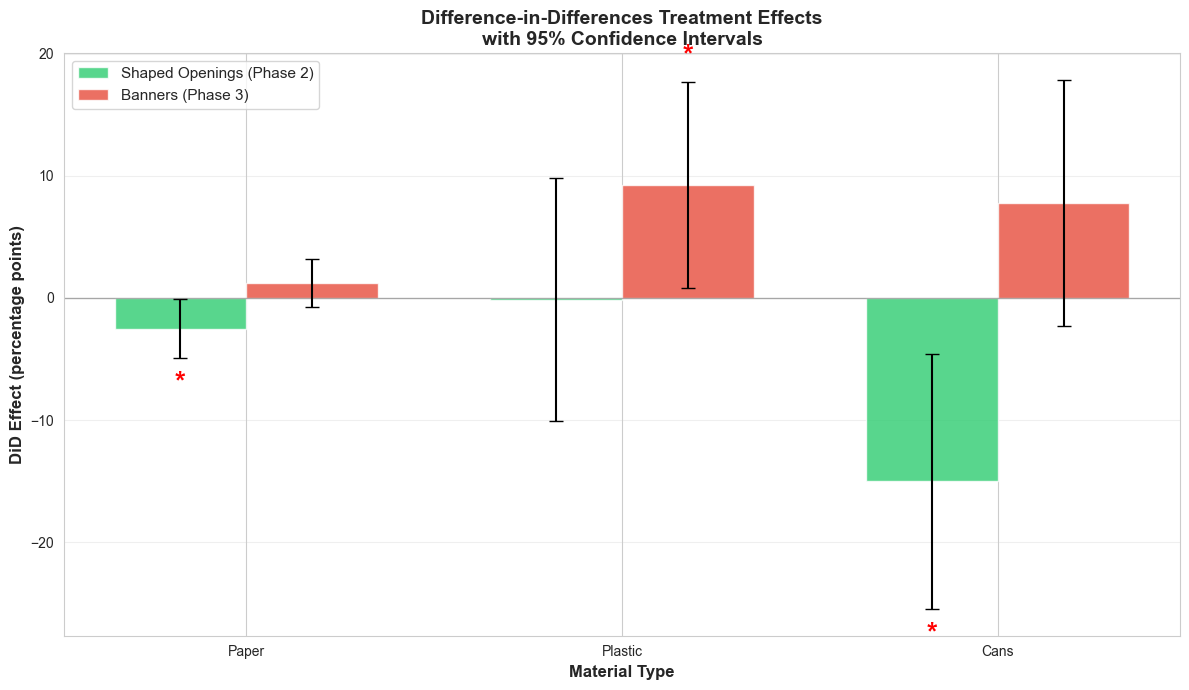


* = Statistically significant at p < 0.05


In [28]:
# Visualization of DiD effects with error bars
fig, ax = plt.subplots(figsize=(12, 7))

# Prepare data for plotting
materials = ['Paper', 'Plastic', 'Cans']
x_pos = np.arange(len(materials))
width = 0.35

# Phase 2 data
phase2_effects = [
    results_phase2['PaperContaminant'].params['PostPhase2:IsUTOWN'],
    results_phase2['PlasticContaminant'].params['PostPhase2:IsUTOWN'],
    results_phase2['CanContaminant'].params['PostPhase2:IsUTOWN']
]
phase2_errors = [
    results_phase2['PaperContaminant'].bse['PostPhase2:IsUTOWN'] * 1.96,  # 95% CI
    results_phase2['PlasticContaminant'].bse['PostPhase2:IsUTOWN'] * 1.96,
    results_phase2['CanContaminant'].bse['PostPhase2:IsUTOWN'] * 1.96
]

# Phase 3 data
phase3_effects = [
    results_phase3['PaperContaminant'].params['PostPhase3:IsUTOWN'],
    results_phase3['PlasticContaminant'].params['PostPhase3:IsUTOWN'],
    results_phase3['CanContaminant'].params['PostPhase3:IsUTOWN']
]
phase3_errors = [
    results_phase3['PaperContaminant'].bse['PostPhase3:IsUTOWN'] * 1.96,
    results_phase3['PlasticContaminant'].bse['PostPhase3:IsUTOWN'] * 1.96,
    results_phase3['CanContaminant'].bse['PostPhase3:IsUTOWN'] * 1.96
]

# Create bars
bars1 = ax.bar(x_pos - width/2, phase2_effects, width, label='Shaped Openings (Phase 2)',
               color='#2ecc71', alpha=0.8, yerr=phase2_errors, capsize=5)
bars2 = ax.bar(x_pos + width/2, phase3_effects, width, label='Banners (Phase 3)',
               color='#e74c3c', alpha=0.8, yerr=phase3_errors, capsize=5)

# Add horizontal line at zero
ax.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.3)

# Customize
ax.set_xlabel('Material Type', fontsize=12, fontweight='bold')
ax.set_ylabel('DiD Effect (percentage points)', fontsize=12, fontweight='bold')
ax.set_title('Difference-in-Differences Treatment Effects\nwith 95% Confidence Intervals', 
             fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(materials)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

# Add significance markers
def add_significance(bars, effects, errors, phase):
    for i, (bar, effect) in enumerate(zip(bars, effects)):
        height = bar.get_height()
        # Get p-value
        if phase == 2:
            contaminant = ['PaperContaminant', 'PlasticContaminant', 'CanContaminant'][i]
            p_val = results_phase2[contaminant].pvalues['PostPhase2:IsUTOWN']
        else:
            contaminant = ['PaperContaminant', 'PlasticContaminant', 'CanContaminant'][i]
            p_val = results_phase3[contaminant].pvalues['PostPhase3:IsUTOWN']
        
        if p_val < 0.05:
            marker = '*' if p_val < 0.05 else ''
            y_pos = height + errors[i] + 1 if height > 0 else height - errors[i] - 1
            ax.text(bar.get_x() + bar.get_width()/2, y_pos, marker,
                   ha='center', va='bottom' if height > 0 else 'top', 
                   fontsize=20, fontweight='bold', color='red')

add_significance(bars1, phase2_effects, phase2_errors, 2)
add_significance(bars2, phase3_effects, phase3_errors, 3)

plt.tight_layout()
plt.savefig('did_effects_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n* = Statistically significant at p < 0.05")

### 6.3 Visualization of DiD Effects

In [29]:
# Create comprehensive results table
results_summary = pd.DataFrame({
    'Material': ['Paper', 'Paper', 'Plastic', 'Plastic', 'Cans', 'Cans'],
    'Intervention': ['Shaped Openings (Phase 2)', 'Banners (Phase 3)', 
                     'Shaped Openings (Phase 2)', 'Banners (Phase 3)',
                     'Shaped Openings (Phase 2)', 'Banners (Phase 3)'],
    'DiD Estimate (δ)': [
        results_phase2['PaperContaminant'].params['PostPhase2:IsUTOWN'],
        results_phase3['PaperContaminant'].params['PostPhase3:IsUTOWN'],
        results_phase2['PlasticContaminant'].params['PostPhase2:IsUTOWN'],
        results_phase3['PlasticContaminant'].params['PostPhase3:IsUTOWN'],
        results_phase2['CanContaminant'].params['PostPhase2:IsUTOWN'],
        results_phase3['CanContaminant'].params['PostPhase3:IsUTOWN']
    ],
    'Std Error': [
        results_phase2['PaperContaminant'].bse['PostPhase2:IsUTOWN'],
        results_phase3['PaperContaminant'].bse['PostPhase3:IsUTOWN'],
        results_phase2['PlasticContaminant'].bse['PostPhase2:IsUTOWN'],
        results_phase3['PlasticContaminant'].bse['PostPhase3:IsUTOWN'],
        results_phase2['CanContaminant'].bse['PostPhase2:IsUTOWN'],
        results_phase3['CanContaminant'].bse['PostPhase3:IsUTOWN']
    ],
    'P-value': [
        results_phase2['PaperContaminant'].pvalues['PostPhase2:IsUTOWN'],
        results_phase3['PaperContaminant'].pvalues['PostPhase3:IsUTOWN'],
        results_phase2['PlasticContaminant'].pvalues['PostPhase2:IsUTOWN'],
        results_phase3['PlasticContaminant'].pvalues['PostPhase3:IsUTOWN'],
        results_phase2['CanContaminant'].pvalues['PostPhase2:IsUTOWN'],
        results_phase3['CanContaminant'].pvalues['PostPhase3:IsUTOWN']
    ]
})

# Add significance indicator
results_summary['Significant'] = results_summary['P-value'].apply(lambda p: '✅ Yes' if p < 0.05 else '❌ No')

# Add 95% confidence intervals
results_summary['95% CI Lower'] = [
    results_phase2['PaperContaminant'].conf_int().loc['PostPhase2:IsUTOWN', 0],
    results_phase3['PaperContaminant'].conf_int().loc['PostPhase3:IsUTOWN', 0],
    results_phase2['PlasticContaminant'].conf_int().loc['PostPhase2:IsUTOWN', 0],
    results_phase3['PlasticContaminant'].conf_int().loc['PostPhase3:IsUTOWN', 0],
    results_phase2['CanContaminant'].conf_int().loc['PostPhase2:IsUTOWN', 0],
    results_phase3['CanContaminant'].conf_int().loc['PostPhase3:IsUTOWN', 0]
]

results_summary['95% CI Upper'] = [
    results_phase2['PaperContaminant'].conf_int().loc['PostPhase2:IsUTOWN', 1],
    results_phase3['PaperContaminant'].conf_int().loc['PostPhase3:IsUTOWN', 1],
    results_phase2['PlasticContaminant'].conf_int().loc['PostPhase2:IsUTOWN', 1],
    results_phase3['PlasticContaminant'].conf_int().loc['PostPhase3:IsUTOWN', 1],
    results_phase2['CanContaminant'].conf_int().loc['PostPhase2:IsUTOWN', 1],
    results_phase3['CanContaminant'].conf_int().loc['PostPhase3:IsUTOWN', 1]
]

print("="*100)
print("DIFFERENCE-IN-DIFFERENCES RESULTS SUMMARY")
print("="*100)
print(results_summary.round(4))

# Export to CSV for report
results_summary.to_csv('did_results_summary.csv', index=False)
print("\n✅ Results exported to 'did_results_summary.csv'")

DIFFERENCE-IN-DIFFERENCES RESULTS SUMMARY
  Material               Intervention  DiD Estimate (δ)  Std Error  P-value  \
0    Paper  Shaped Openings (Phase 2)           -2.5234     1.2441   0.0477   
1    Paper          Banners (Phase 3)            1.2188     1.0216   0.2399   
2  Plastic  Shaped Openings (Phase 2)           -0.1387     5.0809   0.9783   
3  Plastic          Banners (Phase 3)            9.2385     4.3147   0.0384   
4     Cans  Shaped Openings (Phase 2)          -15.0244     5.3366   0.0069   
5     Cans          Banners (Phase 3)            7.7813     5.1473   0.1385   

  Significant  95% CI Lower  95% CI Upper  
0       ✅ Yes       -5.0198       -0.0270  
1        ❌ No       -0.8460        3.2836  
2        ❌ No      -10.3343       10.0569  
3       ✅ Yes        0.5182       17.9589  
4       ✅ Yes      -25.7331       -4.3157  
5        ❌ No       -2.6218       18.1844  

✅ Results exported to 'did_results_summary.csv'
